In [100]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import shap

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

In [101]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [102]:
!ls

comparativa_roc_auc.png     dataset_unificat.csv       matriu_confusio_mlp.png
correlation_heatmap.png     datos_UOC_diabetes.txt     matriu_confusio_rl.png
dades_powerbi.csv	    datos_UOC_nodiabetes.txt   shap_summary_plot.png
dataset_pivotat.csv	    datos_UOC_sintomas.txt     TFM.ipynb
dataset_pivotat_estand.csv  distribucio_sexe_edat.png


In [103]:
cd /content/drive/MyDrive/TFM 25-26

/content/drive/MyDrive/TFM 25-26


In [104]:
# Carreguem els datasets
df_diabetis = pd.read_csv('datos_UOC_diabetes.txt')
df_nodiabetis = pd.read_csv('datos_UOC_nodiabetes.txt')
df_simptomes = pd.read_csv('datos_UOC_sintomas.txt', sep='\t', header=None, skiprows=1, names=['ID', 'Simptomes'])

# Afegim la variable objectiu
df_diabetis['Diabetis'] = 1
df_nodiabetis['Diabetis'] = 0

# Concatenem les dades
df_clinical = pd.concat([df_diabetis, df_nodiabetis], ignore_index=True)

In [105]:
# Eliminem duplicats en els símptomes per no duplicar registres clínics al fer el merge
df_simptomes = df_simptomes.drop_duplicates()

# Funció per extreure els diferents factors de risc qu ens interessen
def extract_risk_factors(symptom_str):
    if pd.isna(symptom_str):
        return []

    parts = [p.strip().lower() for p in str(symptom_str).split(',')]

    factors = [p for p in parts if 'diabetes' not in p and p not in ['sin sintomas', 'sin diagnostico']]
    return factors

# Fem una llista amb els factors únics
all_factors = set()
df_simptomes['Llista de risc'] = df_simptomes['Simptomes'].apply(extract_risk_factors)
for factors in df_simptomes['Llista de risc']:
    all_factors.update(factors)

print("Factors de risc detectats:", all_factors)

# Creem una columna binària per cada factor
for factor in all_factors:
    df_simptomes[factor] = df_simptomes['Llista de risc'].apply(lambda x: 1 if factor in x else 0)

# Eliminem les columnes temporals
df_simptomes_final = df_simptomes.drop(columns=['Simptomes', 'Llista de risc'])

# Fem un left join per mantenir totes les dades clíniques encara que no tinguin símptomes registrats
df_unif = pd.merge(df_clinical, df_simptomes_final, on='ID', how='left')

# Omplim els NaNs amb 0
for factor in all_factors:
    df_unif[factor] = df_unif[factor].fillna(0).astype(int)

# Mostrem la informació del resultat
print("\nEstructura del Dataset unificat:")
print(df_unif.info())
print("\nExemple de dades:")
print(df_unif.head())

# Guardem el resultat en un nou csv
df_unif.to_csv('dataset_unificat.csv', index=False)

Factors de risc detectats: {'sed habitual y necesidad de beber', 'vision borrosa', 'sedentarismo', 'sobrepeso', 'hipertension', 'hipotension', 'hiperlipidemia', 'anemia', 'fatiga', 'obesidad'}

Estructura del Dataset unificat:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84291 entries, 0 to 84290
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   ID                                 84291 non-null  object 
 1   Fecha                              84291 non-null  object 
 2   Edad                               84291 non-null  int64  
 3   Sexo                               84291 non-null  object 
 4   Prueba                             84291 non-null  object 
 5   Resultado                          84291 non-null  float64
 6   Rango_Inferior                     84291 non-null  float64
 7   Rango_Superior                     84291 non-null  int64  
 8   Diabetis           

In [106]:
# Carreguem les dades
df = pd.read_csv('dataset_unificat.csv')

# Convertim la columna Fecha a format datetime
df['Fecha'] = pd.to_datetime(df['Fecha'], dayfirst=True)

# Ordenem: primer per ID i després per Fecha de més recent a més antiga
df = df.sort_values(by=['ID', 'Fecha'], ascending=[True, True])

# Abans de pivotar, hem de garantir que les dades "estàtiques" (Edad, Sexo, Símptomes)
# siguin les de la visita més recent per a cada pacient
static_cols = ['ID', 'Edad', 'Sexo', 'Diabetis']
symptom_cols = [c for c in df.columns if c not in static_cols + ['Fecha', 'Prueba', 'Resultado', 'Rango_Inferior', 'Rango_Superior']]

# Creem un dataframe amb la info més recent de cada pacient
df_info_pacient = df.drop_duplicates(subset=['ID'], keep='first')[static_cols + symptom_cols]

# Per a cada prova de cada pacient, ens quedem només amb la més antiga (el moment on se'ls detecta que tenen diabetis).
df_proves_recents = df.drop_duplicates(subset=['ID', 'Prueba'], keep='first')[['ID', 'Prueba', 'Resultado']]

# Ajuntem les proves recents amb la info del pacient
df_final = pd.merge(df_proves_recents, df_info_pacient, on='ID')

# Mapegem el sexe
df_final['Sexo'] = df_final['Sexo'].map({'Hombre': 1, 'Mujer': 2})

#Pivotem la taula
df_pivoted = df_final.pivot_table(index=static_cols + symptom_cols,
                                columns='Prueba',
                                values='Resultado',
                                aggfunc='first').reset_index()

# Generem estadístiques
stats = df_pivoted[['Edad', 'Sexo', 'Diabetis'] + df['Prueba'].unique().tolist()].describe().T
print(stats[['mean', 'std', 'min', 'max']])

# Guardem el resultat
df_pivoted.to_csv('dataset_pivotat.csv', index=False)

                      mean        std     min     max
Prueba                                               
Edad             60.113667  15.845723  13.000   100.0
Sexo              1.499000   0.500041   1.000     2.0
Diabetis          0.500000   0.500042   0.000     1.0
Colesterol      194.938193  40.477939  67.000   586.0
HDL-Colesterol   54.808319  15.557163  14.000   159.0
LDL-Calculado   112.492817  35.571445  12.000   707.6
Trigliceridos   138.834909  96.149215   1.075  1520.0
Hb-Glicosilada    6.498639   1.499315   4.200    16.1


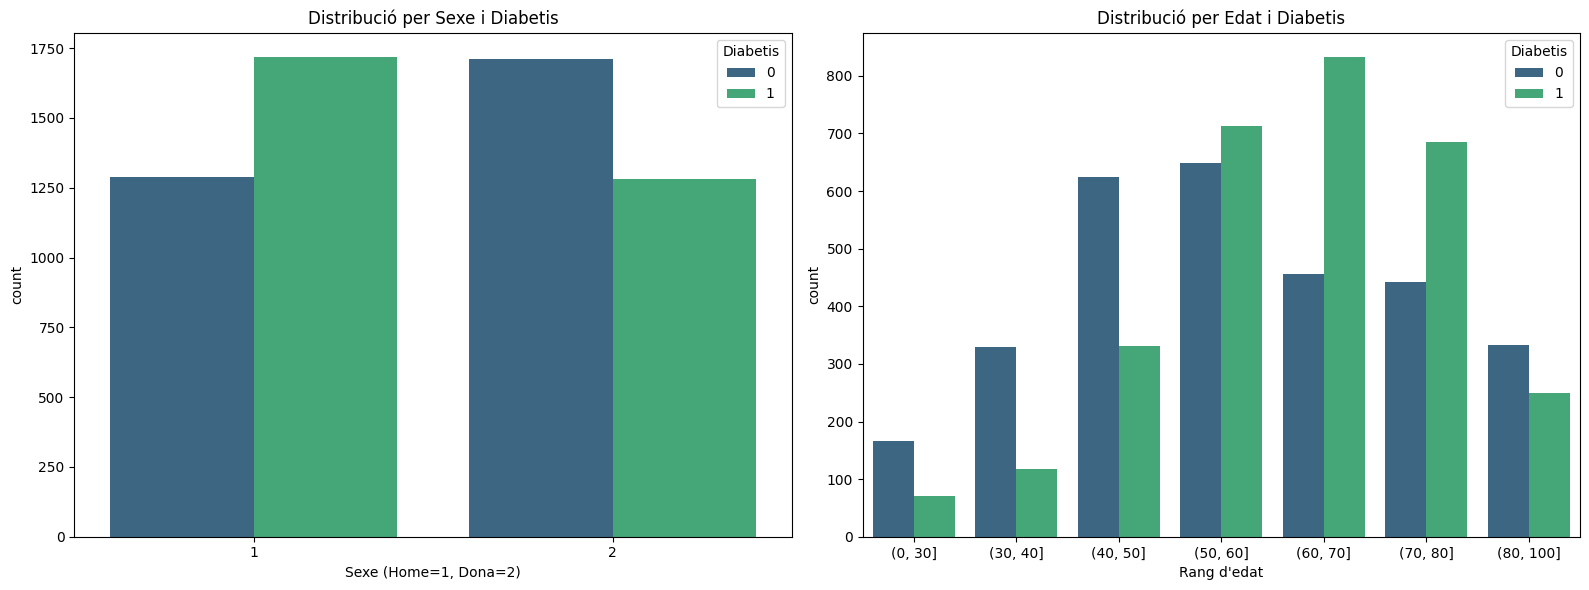

In [107]:
# Generem gràfics de distribució per sexe i edat
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=df_pivoted, x='Sexo', hue='Diabetis', ax=axes[0], palette='viridis')
axes[0].set_title('Distribució per Sexe i Diabetis')
axes[0].set_xlabel('Sexe (Home=1, Dona=2)')

df_pivoted['Rang_Edat'] = pd.cut(df_pivoted['Edad'], bins=[0, 30, 40, 50, 60, 70, 80, 100])
sns.countplot(data=df_pivoted, x='Rang_Edat', hue='Diabetis', ax=axes[1], palette='viridis')
axes[1].set_xlabel("Rang d'edat")
axes[1].set_title('Distribució per Edat i Diabetis')
plt.tight_layout()
#plt.savefig('distribucio_sexe_edat.png')

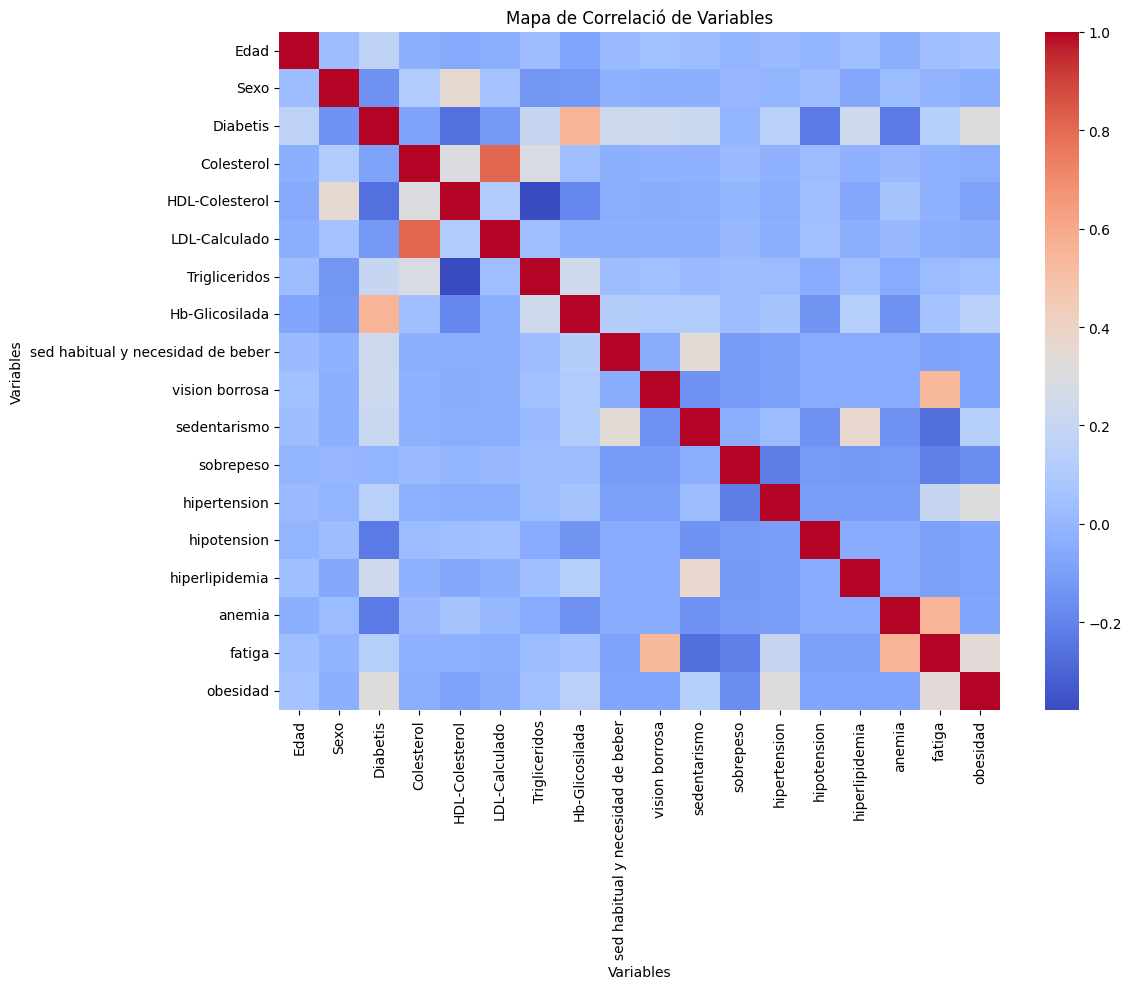

In [108]:
# Generem un mapa de calor
plt.figure(figsize=(12, 10))

# Seleccionem només les variables numèriques per la correlació
corr_cols = ['Edad', 'Sexo', 'Diabetis'] + df['Prueba'].unique().tolist() + symptom_cols
corr_matrix = df_pivoted[corr_cols].corr()
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.xlabel('Variables')
plt.ylabel('Variables')
plt.title('Mapa de Correlació de Variables')
plt.tight_layout()
#plt.savefig('correlation_heatmap.png')

In [109]:
test_cols = df_final['Prueba'].unique().tolist()

# Tractem els valors nuls (alguns pacients poden no tenir totes les proves)
# Omplim amb la mediana per no distorsionar amb possibles outliers
for col in test_cols:
    if col in df_pivoted.columns:
        df_pivoted[col] = df_pivoted[col].fillna(df_pivoted[col].median())

# Tractem els outliers (Winsorization)
# Limitem els valors al percentil 1 i 99 per evitar extrems com el colesterol de 862
for col in test_cols:
    if col in df_pivoted.columns:
        lower_limit = df_pivoted[col].quantile(0.01)
        upper_limit = df_pivoted[col].quantile(0.99)
        df_pivoted[col] = np.clip(df_pivoted[col], lower_limit, upper_limit)

# Escalem les variables amb StandardScaler, que centra les dades a mitjana 0 i desviació estàndard 1
scaler = StandardScaler()
cols_to_scale = ['Edad'] + test_cols
df_pivoted_scaled = df_pivoted.copy()
df_pivoted_scaled[cols_to_scale] = scaler.fit_transform(df_pivoted[cols_to_scale])

# Guardem el resultat
df_pivoted_scaled.to_csv('dataset_pivotat_estand.csv', index=False)

In [110]:
# Carreguem el dataset preparat pels models
df = pd.read_csv('dataset_pivotat_estand.csv')

# Separem variables predictores i la variable objectiu
X = df.drop(columns=['ID', 'Rang_Edat' ,'Diabetis'])
y = df['Diabetis']

# Fem l'split entre train i test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Mida del conjunt d'entrenament (Train): {X_train.shape[0]} pacients")
print(f"Mida del conjunt de prova (Test): {X_test.shape[0]} pacients")

Mida del conjunt d'entrenament (Train): 4800 pacients
Mida del conjunt de prova (Test): 1200 pacients


In [111]:
# Entrenem el model de Regressió Logística
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

# Fem les prediccions
y_pred = lr_model.predict(X_test)

# Avaluem els resultats
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [112]:
# Creem un DataFrame buit amb els resultats dels diferents models que avaluem
lr_results = {
    "model": "Regressió Logística",
    "accuracy": round(accuracy, 4),
    "precision": round(precision, 4),
    "recall": round(recall, 4),
    "f1_score": round(f1, 4)
}

results_df = pd.DataFrame.from_dict([lr_results])

print('Taula de Resultats Global:\n')
print(results_df)

Taula de Resultats Global:

                 model  accuracy  precision  recall  f1_score
0  Regressió Logística    0.9158     0.9447  0.8833     0.913


In [113]:
print("Informe complet pel model de Regressió Logística:")
print(classification_report(y_test, y_pred))

Informe complet pel model de Regressió Logística:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92       600
           1       0.94      0.88      0.91       600

    accuracy                           0.92      1200
   macro avg       0.92      0.92      0.92      1200
weighted avg       0.92      0.92      0.92      1200



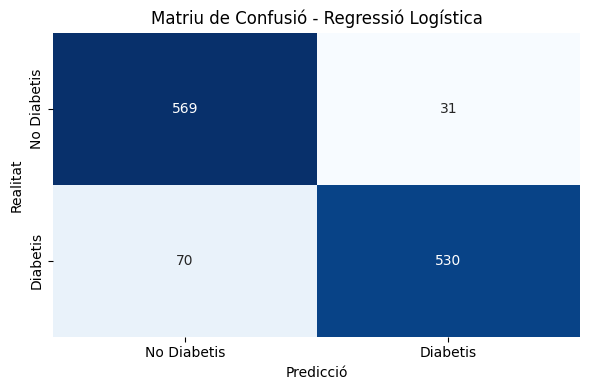

In [114]:
# Generem la matriu de confusió
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Diabetis', 'Diabetis'],
            yticklabels=['No Diabetis', 'Diabetis'])
plt.xlabel('Predicció')
plt.ylabel('Realitat')
plt.title('Matriu de Confusió - Regressió Logística')
plt.tight_layout()
#plt.savefig('matriu_confusio_rl.png')

In [115]:
# Entrenem el model Random Forest
rf_model = RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced')
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# Entrenem el model XGBoost donant més pes als diabètics
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=1.2)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

In [116]:
# Creem funció per avaluar els resultats
def avaluar_model(nom, y_test, prediccions):
    global results_df

    accuracy = accuracy_score(y_test, prediccions)
    precision = precision_score(y_test, prediccions)
    recall = recall_score(y_test, prediccions)
    f1 = f1_score(y_test, prediccions)

    model_results = {
    "model": nom,
    "accuracy": round(accuracy, 4),
    "precision": round(precision, 4),
    "recall": round(recall, 4),
    "f1_score": round(f1, 4)
    }

    # Afegim la fila a la taula de resultats
    results_df = pd.concat([results_df, pd.DataFrame([model_results])], ignore_index=True)

    return confusion_matrix(y_test, prediccions)

cm_rf = avaluar_model("Random Forest", y_test, rf_pred)
cm_xgb = avaluar_model("XGBoost", y_test, xgb_pred)

print('Taula de Resultats Global:\n')
print(results_df)

Taula de Resultats Global:

                 model  accuracy  precision  recall  f1_score
0  Regressió Logística    0.9158     0.9447  0.8833    0.9130
1        Random Forest    0.9442     0.9556  0.9317    0.9435
2              XGBoost    0.9417     0.9476  0.9350    0.9413


In [117]:
print("Informe complet pel model de Random Forest:")
print(classification_report(y_test, rf_pred))

print("\nInforme complet pel model de XGBoost:")
print(classification_report(y_test, xgb_pred))

Informe complet pel model de Random Forest:
              precision    recall  f1-score   support

           0       0.93      0.96      0.94       600
           1       0.96      0.93      0.94       600

    accuracy                           0.94      1200
   macro avg       0.94      0.94      0.94      1200
weighted avg       0.94      0.94      0.94      1200


Informe complet pel model de XGBoost:
              precision    recall  f1-score   support

           0       0.94      0.95      0.94       600
           1       0.95      0.94      0.94       600

    accuracy                           0.94      1200
   macro avg       0.94      0.94      0.94      1200
weighted avg       0.94      0.94      0.94      1200



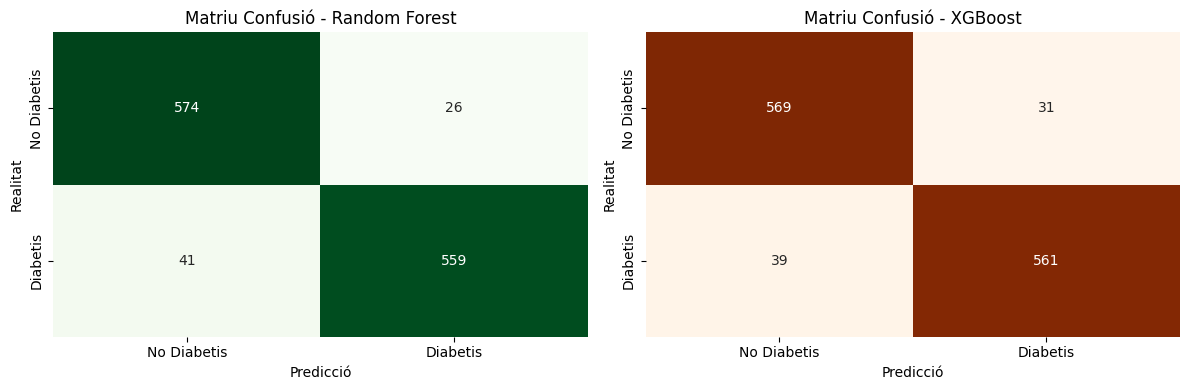

In [118]:
# Dibuixem les matrius de confusió comparatives
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[0],
            xticklabels=['No Diabetis', 'Diabetis'], yticklabels=['No Diabetis', 'Diabetis'])
axes[0].set_title('Matriu Confusió - Random Forest')
axes[0].set_xlabel('Predicció')
axes[0].set_ylabel('Realitat')

sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', cbar=False, ax=axes[1],
            xticklabels=['No Diabetis', 'Diabetis'], yticklabels=['No Diabetis', 'Diabetis'])
axes[1].set_title('Matriu Confusió - XGBoost')
axes[1].set_xlabel('Predicció')
axes[1].set_ylabel('Realitat')

plt.tight_layout()
plt.show()

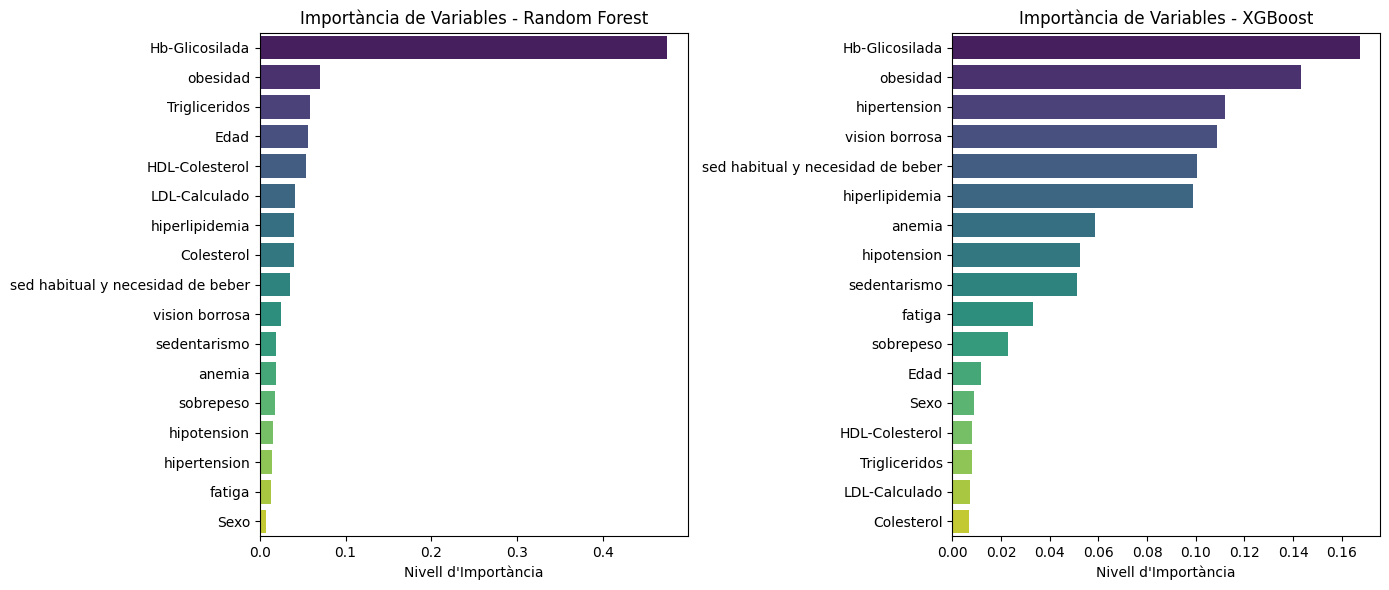

In [119]:
# Creem una funció per determinar la importància de cada variable per la decisió de cada model
def plot_feature_importance(model, feature_names, title, ax):

    importances = model.feature_importances_

    df_imp = pd.DataFrame({
        'Variable': feature_names,
        'Importància': importances
    }).sort_values(by='Importància', ascending=False)

    sns.barplot(x='Importància', y='Variable', data=df_imp, ax=ax, palette='viridis', hue='Variable', legend=False)
    ax.set_title(title)
    ax.set_xlabel('Nivell d\'Importància')
    ax.set_ylabel('')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

noms_variables = X_train.columns

# Generem els gràfics
plot_feature_importance(rf_model, noms_variables, 'Importància de Variables - Random Forest', axes[0])
plot_feature_importance(xgb_model, noms_variables, 'Importància de Variables - XGBoost', axes[1])

plt.tight_layout()
plt.show()

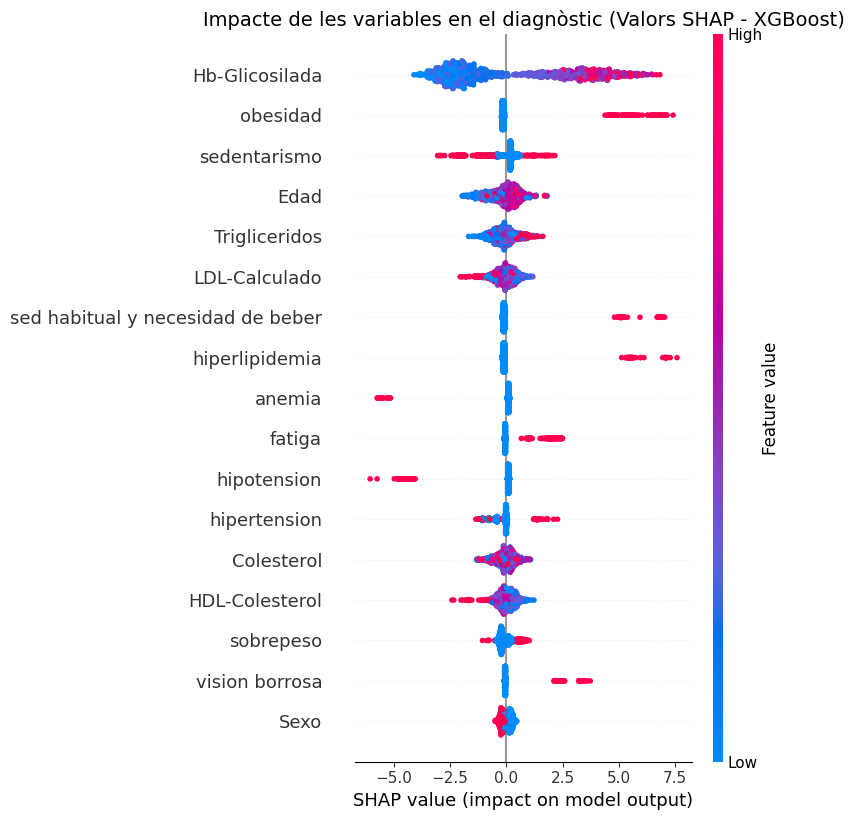

In [120]:
# Utilitzem l'explicador d'arbres de SHAP pel model XGBoost
explainer = shap.TreeExplainer(xgb_model)

# Calculem els valors SHAP
shap_values = explainer.shap_values(X_test)

# Generar el gràfic resultant
plt.figure(figsize=(10, 8))
plt.title("Impacte de les variables en el diagnòstic (Valors SHAP - XGBoost)", fontsize=14)
shap.summary_plot(shap_values, X_test, show=False)

plt.tight_layout()
plt.show()
#plt.savefig('shap_summary_plot.png')

In [121]:
# Pel model de DNN utilitzarem un càlcul de pesos per combatre el desequilibri de classes i millorar el recall
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
pesos_classes = dict(enumerate(class_weights))

# Construcció de la Xarxa Neuronal - Perceptró Multicapa (MLP)
model_nn = Sequential([
    # Capa d'entrada i 1a Capa Oculta
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    # 2a Capa Oculta
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    # Capa de Sortida
    Dense(1, activation='sigmoid')
])

# Compilem el model utilitzant binary_crossentropy per classificació binària
optimitzador = Adam(learning_rate=0.001)
model_nn.compile(optimizer=optimitzador, loss='binary_crossentropy', metrics=['accuracy', 'Recall'])

# Definim un Early Stopping, per aturar si no millora el conjunt de validació
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# Comencem l'entrenament de la xarxa neuronal
history = model_nn.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    class_weight=pesos_classes,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - Recall: 0.7513 - accuracy: 0.7589 - loss: 0.5214 - val_Recall: 0.9198 - val_accuracy: 0.8656 - val_loss: 0.4154
Epoch 2/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Recall: 0.8406 - accuracy: 0.8529 - loss: 0.3541 - val_Recall: 0.9033 - val_accuracy: 0.9083 - val_loss: 0.2932
Epoch 3/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Recall: 0.8501 - accuracy: 0.8760 - loss: 0.3054 - val_Recall: 0.9033 - val_accuracy: 0.9115 - val_loss: 0.2442
Epoch 4/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Recall: 0.8683 - accuracy: 0.8898 - loss: 0.2846 - val_Recall: 0.9053 - val_accuracy: 0.9156 - val_loss: 0.2253
Epoch 5/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Recall: 0.8798 - accuracy: 0.8909 - loss: 0.2723 - val_Recall: 0.9095 - val_accuracy: 0.9208 - val_loss: 0.2133
Epoch 6/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Recall: 0.8793 - accuracy: 0.8984 - loss: 0.2593 - val_Recall: 0.9136 - val_accuracy: 0.9219 - val_loss: 0.202

In [122]:
# Generem l'avaluació i predicció del model (les convertim a 1 o 0 si supera el 0.5)
nn_pred_prob = model_nn.predict(X_test)
nn_pred_binari = (nn_pred_prob > 0.5).astype(int).flatten()

accuracy = accuracy_score(y_test, nn_pred_binari)
precision = precision_score(y_test, nn_pred_binari)
recall = recall_score(y_test, nn_pred_binari)
f1 = f1_score(y_test, nn_pred_binari)

dnn_results = {
    "model": "Xarxa neuronal - MLP",
    "accuracy": round(accuracy, 4),
    "precision": round(precision, 4),
    "recall": round(recall, 4),
    "f1_score": round(f1, 4)
}

# Afegim la fila a la taula de resultats
results_df = pd.concat([results_df, pd.DataFrame([dnn_results])], ignore_index=True)

print('Taula de Resultats Global:\n')
print(results_df)

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Taula de Resultats Global:

                  model  accuracy  precision  recall  f1_score
0   Regressió Logística    0.9158     0.9447  0.8833    0.9130
1         Random Forest    0.9442     0.9556  0.9317    0.9435
2               XGBoost    0.9417     0.9476  0.9350    0.9413
3  Xarxa neuronal - MLP    0.9417     0.9617  0.9200    0.9404


In [123]:
print("Informe complet pel model de Perceptró Multicapa (DNN):")
print(classification_report(y_test, nn_pred_binari))

Informe complet pel model de Perceptró Multicapa (DNN):
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       600
           1       0.96      0.92      0.94       600

    accuracy                           0.94      1200
   macro avg       0.94      0.94      0.94      1200
weighted avg       0.94      0.94      0.94      1200



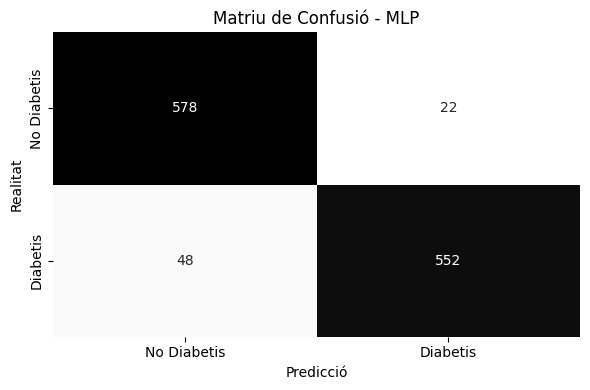

In [124]:
# Generem la matriu de confusió
cm = confusion_matrix(y_test, nn_pred_binari)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greys', cbar=False,
            xticklabels=['No Diabetis', 'Diabetis'],
            yticklabels=['No Diabetis', 'Diabetis'])
plt.xlabel('Predicció')
plt.ylabel('Realitat')
plt.title('Matriu de Confusió - MLP')
plt.tight_layout()
#plt.savefig('matriu_confusio_mlp.png')

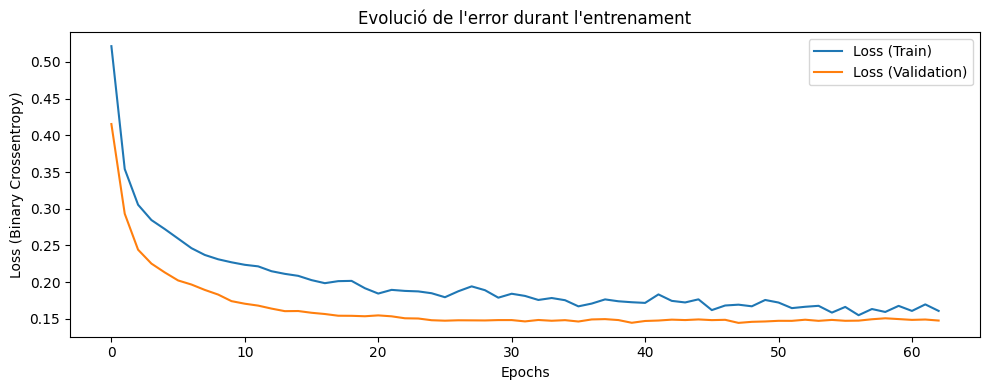

In [125]:
# Mostrem el gràfic de l'evolució de l'aprenentatge
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Loss (Train)')
plt.plot(history.history['val_loss'], label='Loss (Validation)')
plt.title('Evolució de l\'error durant l\'entrenament')
plt.xlabel('Epochs')
plt.ylabel('Loss (Binary Crossentropy)')
plt.legend()
plt.tight_layout()
plt.show()

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


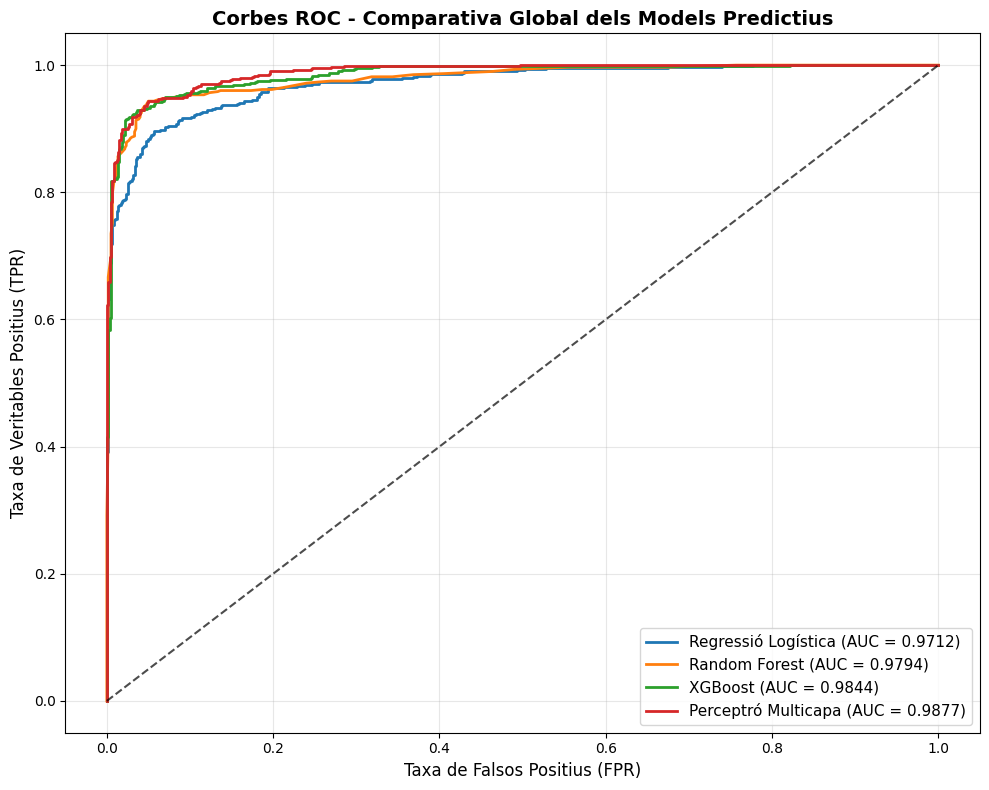

In [126]:
# Obtenim les probabilitats de cada model
lr_prob = lr_model.predict_proba(X_test)[:, 1]
rf_prob = rf_model.predict_proba(X_test)[:, 1]
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
nn_prob = model_nn.predict(X_test).flatten()

# Calculem els punts de la corba ROC (FPR, TPR) i l'AUC per a cada model
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
auc_lr = auc(fpr_lr, tpr_lr)

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
auc_rf = auc(fpr_rf, tpr_rf)

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_prob)
auc_xgb = auc(fpr_xgb, tpr_xgb)

fpr_nn, tpr_nn, _ = roc_curve(y_test, nn_prob)
auc_nn = auc(fpr_nn, tpr_nn)

# Dibuixem el gràfic comparatiu
plt.figure(figsize=(10, 8))

plt.plot(fpr_lr, tpr_lr, label=f'Regressió Logística (AUC = {auc_lr:.4f})', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.4f})', linewidth=2)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.4f})', linewidth=2)
plt.plot(fpr_nn, tpr_nn, label=f'Perceptró Multicapa (AUC = {auc_nn:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.7)

plt.xlabel('Taxa de Falsos Positius (FPR)', fontsize=12)
plt.ylabel('Taxa de Veritables Positius (TPR)', fontsize=12)
plt.title('Corbes ROC - Comparativa Global dels Models Predictius', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)

plt.tight_layout()
#plt.savefig('comparativa_roc_auc.png', dpi=300)
plt.show()

In [127]:
# Carreguem les dades sense escalar
df_original = pd.read_csv('dataset_pivotat.csv')

# Ens assegurem que l'ordre de les files sigui exactament el mateix que quan vam entrenar
# Per fer-ho, agafarem tot el dataset preparat i calcularem les prediccions per a tots els pacients
df_ready = pd.read_csv('dataset_pivotat_estand.csv')
X_all = df_ready.drop(columns=['ID', 'Rang_Edat', 'Diabetis'])

# Obtenim les probabilitats i prediccions amb l'XGBoost
probabilitat_xgb = xgb_model.predict_proba(X_all)[:, 1] * 100
prediccio_xgb = xgb_model.predict(X_all)

# Calculem els valors SHAP per a tots els pacients
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_all)

# Construim el dataFrame final per a Power BI
df_pbi = df_original.copy()

# Afegim les prediccions de la IA
df_pbi['IA_Probabilitat_Diabetis_%'] = probabilitat_xgb.round(1)
df_pbi['IA_Diagnòstic'] = prediccio_xgb

# Fem una petita transformació perquè quedi més llegible
df_pbi['Risc_Classificació'] = pd.cut(df_pbi['IA_Probabilitat_Diabetis_%'],
                                      bins=[-1, 30, 60, 100],
                                      labels=['Risc Baix', 'Risc Moderat', 'Risc Alt'])

# Afegim els valors SHAP de les variables més importants
noms_columnes_shap = X_all.columns
for i, col in enumerate(noms_columnes_shap):
    # Només agafarem els SHAP de les 6 variables més importants per no saturar el PBI
    if col in ['Hb-Glicosilada', 'Edad', 'Trigliceridos', 'obesidad', 'HDL-Colesterol', 'sedentarismo']:
        df_pbi[f'SHAP_{col}'] = shap_values[:, i].round(3)

# Desmapegem els valors del sexe
df_pbi['Rang_Edat'] = pd.cut(df_pbi['Edad'], bins=[0, 30, 40, 50, 60, 70, 80, 100])
df_pbi['Sexo'] = df_final['Sexo'].map({1: 'Home', 2: 'Dona'})

# Guardem el resultat
df_pbi.to_csv('dades_powerbi.csv', index=False)